In [1]:
#Importar las librerias
from pathlib import Path
import sys

# Carpeta raíz del proyecto
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import os
import pandas as pd
import polars as pl
from procesamiento.PolarPreprocessor import PolarsPreprocessor
import tensorflow as tf
import random
import numpy as np
from modelos.LSTMModel import LSTMModel
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from collections import defaultdict
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')


# Fijar la semilla para los modelos neuronales
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
# ================================
# LSTM
# ================================

# 1. Se realiza el preprocesamiento para generar secuencias al dataset (necesario para el algoritmo)
# Se carga el dataset con la libreria de polars
df_polars = pl.read_csv("/data_simulada/dataset_sintetico_completo.csv")
pol_lstm = PolarsPreprocessor(df_polars)
X, y = pol_lstm.run_all(export_path="/data_simulada/preprocesado_Polars.csv", generar_secuencias = True)

# 2. Se divide el dataset mediante train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# 3. Se obtiene la forma de entrada para el modelo
input_shape = (X_train.shape[1], X_train.shape[2])

# 4. Se inicializa el modelo
lstm_model = LSTMModel(input_shape=input_shape)

# 5. Se procede con el entrenamiento del modelo
history = lstm_model.train(X_train, y_train, X_val=X_test, y_val=y_test, epochs=20, batch_size=64)

Epoch 1/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 49s 49ms/step - accuracy: 0.9783 - loss: 0.0658 - val_accuracy: 0.9944 - val_loss: 0.0157
Epoch 2/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 39s 43ms/step - accuracy: 0.9954 - loss: 0.0144 - val_accuracy: 0.9946 - val_loss: 0.0123
Epoch 3/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 39s 43ms/step - accuracy: 0.9966 - loss: 0.0109 - val_accuracy: 0.9974 - val_loss: 0.0073
Epoch 4/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - accuracy: 0.9967 - loss: 0.0098 - val_accuracy: 0.9971 - val_loss: 0.0069
Epoch 5/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step - accuracy: 0.9974 - loss: 0.0081 - val_accuracy: 0.9974 - val_loss: 0.0067
Epoch 6/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 39s 43ms/step - accuracy: 0.9975 - loss: 0.0074 - val_accuracy: 0.9974 - val_loss: 0.0064
Epoch 7/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 38s 42ms/step - accuracy: 0.9978 - loss: 0.0062 - val_accuracy: 0.9979 - val_loss: 0.0057
Epoch 8/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 38s 42ms/step - accuracy: 0.9982 - loss: 0.0056 - 

449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step
 Accuracy: 0.9986
 ROC AUC: 1.0000

 Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00      3009
         1.0       1.00      1.00      1.00     11343

    accuracy                           1.00     14352
   macro avg       1.00      1.00      1.00     14352
weighted avg       1.00      1.00      1.00     14352


 Confusion Matrix:
[[ 2990    19]
 [    1 11342]]


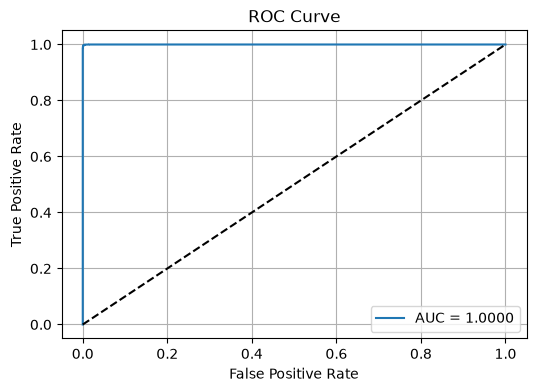

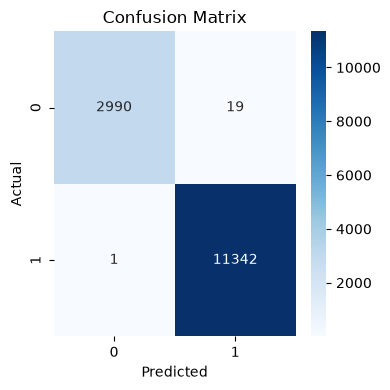

In [3]:
# 6. Se evalua con métricas completas y gráficos
results = lstm_model.evaluate(X_test, y_test, threshold=0.5)

In [7]:
# Se guarda el modelo en el path por defecto
lstm_model.save_model(path='../modelos/lstm_model.keras')

Modelo guardado en: ../modelos/lstm_model.keras


In [9]:
# LSTM: 1 paciente
# 1. Se realiza el preprocesamiento para generar secuencias al dataset (necesario para el algoritmo), en este caso solo para un paciente
df_paciente = df_polars.filter(pl.col("paciente_id") == "PAC_001")
pol_lstm_pac = PolarsPreprocessor(df_paciente)
X_pac, y_pac = pol_lstm_pac.run_all(export_path="/data_simulada/preprocesado_Polars.csv", generar_secuencias = True)


In [10]:
# 2. Se divide el dataset mediante train test split
X_train_pac, X_test_pac, y_train_pac, y_test_pac = train_test_split(X_pac, y_pac, stratify=y_pac, test_size=0.2, random_state=42)

# 3. Se obtiene la forma de entrada para el modelo
input_shape_pac = (X_train_pac.shape[1], X_train_pac.shape[2])

# 4. Se inicializa el modelo
lstm_model_pac = LSTMModel(input_shape=input_shape_pac)

# 5. Se procede con el entrenamiento del modelo
history_pac = lstm_model_pac.train(X_train_pac, y_train_pac, X_val=X_test_pac, y_val=y_test_pac, epochs=20, batch_size=64)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.9450 - loss: 0.1680 - val_accuracy: 0.9434 - val_loss: 0.1358
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.9937 - loss: 0.0208 - val_accuracy: 0.9980 - val_loss: 0.0094
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.9970 - loss: 0.0106 - val_accuracy: 0.9961 - val_loss: 0.0152
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.9972 - loss: 0.0100 - val_accuracy: 0.9980 - val_loss: 0.0063
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.9976 - loss: 0.0071 - val_accuracy: 0.9992 - val_loss: 0.0033
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.9981 - loss: 0.0059 - val_accuracy: 0.9989 - val_loss: 0.0029
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.9985 - loss: 0.0044 - val_accuracy: 0.9992 - val_loss: 0.0026
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.9989 - loss: 0.0039 - 

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
 Accuracy: 0.9992
 ROC AUC: 1.0000

 Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       744
         1.0       1.00      1.00      1.00      2844

    accuracy                           1.00      3588
   macro avg       1.00      1.00      1.00      3588
weighted avg       1.00      1.00      1.00      3588


 Confusion Matrix:
[[ 742    2]
 [   1 2843]]


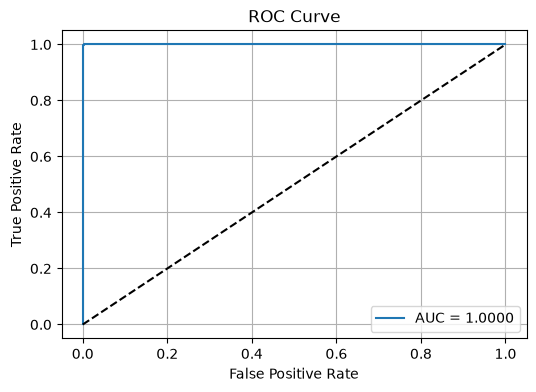

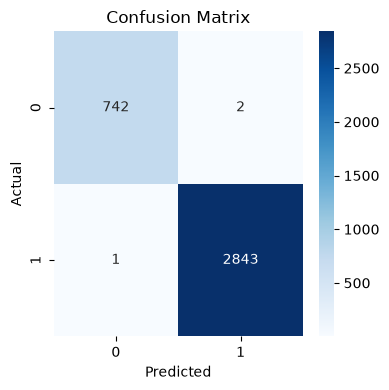

In [14]:
results_pac = lstm_model_pac.evaluate(X_test_pac, y_test_pac, threshold=0.5)

In [15]:
lstm_model_pac.save_model(path="../modelos/lstm_model_pac.keras")

Modelo guardado en: ../modelos/lstm_model_pac.keras


In [16]:
# LSTM: N-1 pacientes (3 pacientes): leave_one_patient_out_validation
def leave_one_patient_out_with_lstm_model(X, y, paciente_ids, input_shape, lstm_params=None,
                                          epochs=10, batch_size=32, verbose=0):
    """
    Validación cruzada Leave-One-Patient-Out usando la clase LSTMModel.

    Args:
        X: np.ndarray (n_samples, seq_len, n_features)
        y: np.ndarray (n_samples,)
        paciente_ids: np.ndarray o list de strings (n_samples,)
        input_shape: tuple (seq_len, n_features)
        lstm_params: dict con hiperparámetros para LSTMModel
        epochs, batch_size: int
        verbose: 0 o 1 para salida de entrenamiento

    Returns:
        resultados: dict con métricas por paciente
    """
    unique_ids = np.unique(paciente_ids)
    all_y_true, all_y_pred, all_y_prob = [], [], []

    resultados = defaultdict(list)

    for pid in tqdm(unique_ids, desc="Validación paciente por paciente"):
        # División de datos
        test_mask = paciente_ids == pid
        train_mask = ~test_mask

        X_train, y_train = X[train_mask], y[train_mask]
        X_test, y_test = X[test_mask], y[test_mask]

        # Nueva instancia del modelo
        model = LSTMModel(input_shape, **(lstm_params or {}))
        model.train(X_train, y_train, batch_size=batch_size, epochs=epochs, use_early_stopping=True)

        # Predicción
        y_pred, y_prob = model.predict(X_test)

        # Métricas por paciente
        acc = np.mean(y_pred.flatten() == y_test)
        try:
            auc = roc_auc_score(y_test, y_prob)
        except:
            auc = None
            warnings.warn(f"No se pudo calcular AUC para {pid} (una sola clase)")

        resultados["paciente"].append(pid)
        resultados["accuracy"].append(acc)
        resultados["roc_auc"].append(auc)

        print(f"\n Paciente {pid} — Accuracy: {acc:.4f}, ROC AUC: {auc if auc else 'N/A'}")
        print(confusion_matrix(y_test, y_pred))
        print(classification_report(y_test, y_pred, digits=3))

        # Acumulados
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred.flatten())
        all_y_prob.extend(y_prob.flatten())

    # Métricas globales
    print("\n Resultados Globales:")
    print(confusion_matrix(all_y_true, all_y_pred))
    print(classification_report(all_y_true, all_y_pred, digits=3))

    try:
        global_auc = roc_auc_score(all_y_true, all_y_prob)
        print(f"ROC AUC global: {global_auc:.4f}")
    except:
        print("ROC AUC global no se pudo calcular")

    return resultados



In [17]:
# 2. Obtener paciente_ids alineados
input_shape = (X.shape[1], X.shape[2])
seq_length = 60
step = 1

exclude_cols = ['timestamp', 'paciente_id', 'empeoramiento']
exclude_keywords = ['etiqueta', 'sostenida']

features = [
    col for col in df_polars.columns
    if col not in exclude_cols and
       not any(kw in col.lower() for kw in exclude_keywords)
]

paciente_ids = []

for paciente_id in df_polars['paciente_id'].unique().to_list():
    grupo = df_polars.filter(pl.col("paciente_id") == paciente_id).select(features + ['empeoramiento'])
    grupo_np = grupo.to_numpy()

    for i in range(0, len(grupo_np) - seq_length, step):
        paciente_ids.append(paciente_id)

paciente_ids = np.array(paciente_ids)

# 3. Validación cruzada LOPO
resultados_lopo = leave_one_patient_out_with_lstm_model(
    X, y, paciente_ids,
    input_shape=input_shape,
    lstm_params={
        'lstm_units_1': 64,
        'lstm_units_2': 32,
        'dense_units': 64,
        'dropout_rate': 0.2,
        'learning_rate': 0.001
    },
    epochs=10,
    batch_size=32,
    verbose=0
)


Validación paciente por paciente:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 66s 36ms/step - accuracy: 0.9833 - loss: 0.0514
Epoch 2/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.9957 - loss: 0.0143
Epoch 3/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 54s 32ms/step - accuracy: 0.9965 - loss: 0.0108
Epoch 4/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 55s 33ms/step - accuracy: 0.9969 - loss: 0.0093
Epoch 5/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.9976 - loss: 0.0072
Epoch 6/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.9978 - loss: 0.0066
Epoch 7/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 55s 32ms/step - accuracy: 0.9980 - loss: 0.0054
Epoch 8/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.9984 - loss: 0.0047
Epoch 9/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.9987 - loss: 0.0041
Epoch 10/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 55s 33ms/step - accuracy: 0.9990 - loss: 0.0036
561/561 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step


Validación paciente por paciente:  25%|██▌       | 1/4 [09:37<28:53, 577.72s/it]


 Paciente PAC_001 — Accuracy: 0.9964, ROC AUC: 0.9999179715738602
[[ 3712    65]
 [    0 14163]]
              precision    recall  f1-score   support

         0.0      1.000     0.983     0.991      3777
         1.0      0.995     1.000     0.998     14163

    accuracy                          0.996     17940
   macro avg      0.998     0.991     0.995     17940
weighted avg      0.996     0.996     0.996     17940

Epoch 1/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 60s 33ms/step - accuracy: 0.9829 - loss: 0.0546
Epoch 2/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 58s 34ms/step - accuracy: 0.9948 - loss: 0.0164
Epoch 3/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 54s 32ms/step - accuracy: 0.9958 - loss: 0.0123
Epoch 4/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 55s 33ms/step - accuracy: 0.9962 - loss: 0.0109
Epoch 5/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 55s 33ms/step - accuracy: 0.9971 - loss: 0.0089
Epoch 6/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.9973 - loss: 0.0077
Epoch 7/10
1682/1682 ━━━━━━━━━━━━━━

Validación paciente por paciente:  50%|█████     | 2/4 [20:23<20:35, 617.58s/it]

...

Validación paciente por paciente:  75%|███████▌  | 3/4 [31:10<10:31, 631.00s/it]


 Paciente PAC_003 — Accuracy: 0.9964, ROC AUC: 0.994991310590451
[[ 3734    56]
 [    9 14141]]
              precision    recall  f1-score   support

         0.0      0.998     0.985     0.991      3790
         1.0      0.996     0.999     0.998     14150

    accuracy                          0.996     17940
   macro avg      0.997     0.992     0.995     17940
weighted avg      0.996     0.996     0.996     17940

Epoch 1/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 74s 37ms/step - accuracy: 0.9839 - loss: 0.0507
Epoch 2/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 63s 37ms/step - accuracy: 0.9956 - loss: 0.0139
Epoch 3/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 65s 38ms/step - accuracy: 0.9963 - loss: 0.0107
Epoch 4/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - accuracy: 0.9970 - loss: 0.0087
Epoch 5/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - accuracy: 0.9973 - loss: 0.0082
Epoch 6/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 65s 38ms/step - accuracy: 0.9978 - loss: 0.0066
Epoch 7/10
1682/1682 ━━━━━━━━━━━━━━━

Validación paciente por paciente: 100%|██████████| 4/4 [42:22<00:00, 635.58s/it]


 Paciente PAC_004 — Accuracy: 0.9569, ROC AUC: 0.9837664981376667
[[ 3380   376]
 [  397 13787]]
              precision    recall  f1-score   support

         0.0      0.895     0.900     0.897      3756
         1.0      0.973     0.972     0.973     14184

    accuracy                          0.957     17940
   macro avg      0.934     0.936     0.935     17940
weighted avg      0.957     0.957     0.957     17940


 Resultados Globales:
[[14538   506]
 [  420 56296]]
              precision    recall  f1-score   support

         0.0      0.972     0.966     0.969     15044
         1.0      0.991     0.993     0.992     56716

    accuracy                          0.987     71760
   macro avg      0.982     0.979     0.980     71760
weighted avg      0.987     0.987     0.987     71760



ROC AUC global: 0.9967
